# Lab 10: The Computational Physics of a Golf Ball?

Our goal today is to build a simulation from the ground up to model the trajectory of a golf ball. We'll discover how gravity, air drag, and the **Magnus effect** (spin) all combine to create the trajectories we see in sports.

**Your task is to run the code cells, analyze the plots, and answer the questions in the 'Analysis' section.**

## The Physics Model

To accurately model the ball, we need to account for three main forces. We'll be working in 2D (x = range, y = height).

### 1. Gravity
The simplest force. It's constant and pulls the ball down.
$$\vec{F}_g = \langle 0, -mg \rangle$$

### 2. Drag Force (Air Resistance)
This force opposes the ball's velocity and is proportional to the square of its speed.
$$\vec{F}_{\textrm{drag}} = -C \rho A v^{2} \hat{v}$$
where:
- $C$ is the drag coefficient
- $\rho$ is the density of air
- $A$ is the cross-sectional area of the ball
- $v$ is the speed of the ball
- $\hat{v}$ is the direction of velocity (a unit vector)

**Crucially, the drag coefficient $C$ is not constant!** This is the secret of the dimples.
- For a **smooth ball**, $C \approx 0.5$ (constant).
- For a **dimpled ball**, $C$ changes with speed:
  - At low speeds ($v < 14$ m/s), $C \approx 0.5$
  - At high speeds ($v > 14$ m/s), $C \approx 7/v$. This sharp drop in drag is the "drag crisis" and it's why dimples are so important!

### 3. Magnus Force (Spin)
This is the effect that makes balls curve. A ball with *backspin* (like a golf drive) generates **lift**.
$$\vec{F}_{\textrm{Magnus}} = \langle -S p_y, S p_x \rangle$$
where $S = (S_0 \omega / m)$ is the spin factor, $p_x$ is the horizontal momentum, and $p_y$ is the vertical momentum.

When the ball is rising ($p_y > 0$), the $x$-component is negative (a small drag effect). But the $y$-component is $S p_x$. Since $p_x$ is positive (moving forward), this creates a **positive lift force** that counteracts gravity!


### 4. Modified air density

The air is "thinner" at higher altitudes. This means the drag and Magnus forces should decrease as the ball flies higher. We'll model this using the **barometric formula**:
$$\rho(y) = \rho_0 e^{-y / y_0}$$
where $\rho_0 = 1.2$ kg/m³ is the air density at sea level and $y_0 \approx 10,400$ m is the "scale height" of the atmosphere.




Let's go back to `scipy.integrate.solve_ivp`

**Key Advantages:**
1.  **Adaptive Time-Stepping:** The solver (e.g., 'RK45') automatically adjusts the time step $\Delta t$ to maintain a specific error tolerance. This is much more efficient and accurate than a fixed `dt`.
2.  **Event Detection:** We can define "events" (like the ball's height `y` crossing zero) and the solver will find the *exact* time they occur and stop the simulation, giving us a highly accurate final range.

## Code Setup

First, let's import the libraries we need and define all our constants. I will let you do this. We need


```
numpy
```

```
matplotlib pyplot
```

```
solve_ivp #look at past code if needed for full call
```

```
from scipy.optimize import minimize_scalar
```



In [ ]:
#imports go here
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import minimize_scalar
# Set up the plotting style for better readability
plt.style.use('seaborn-v0_8-whitegrid')
print("Libraries imported!")


Libraries imported!


## A note: Understanding f-strings (Formatted String Literals)

When you see Python code like `print(f"Value: {variable:.3f}")`, you're looking at an **f-string**.

Here’s a breakdown of how it works:

### 1. The `f` Prefix

The `f` right before the opening quote (`f"..."`) tells Python: "This is a formatted string. Look for curly braces `{}` and treat anything inside them as code to run, not as literal text."

---

### 2. Simple Variable Insertion

This is the most common use. Python replaces the `{variable}` with its current value.

**Example:**
```python
p0 = np.array([12.2, 10.9])
print(f"Initial momentum: {p0}")
```

### 3. Adding Format Instructions
For example in `f"{VALUE : FORMAT}"`


*   `VALUE`: The variable or expression to evaluate (e.g `get_air_density(1433)`).
*  `:` This just separates the variable from the instructions on formatting it
* `FORMAT`: This is code for specifying the format

For example
*   `f`: means "fixed point number", or decimal number
*   `.3`: means "show 3 digits after the deciaml point." Python will round the number if needed.

Other options
*    `:0f` formats as a float with zero decimal places
*    `:.2e` formats in scientific notation.


Example:
```
value_long = 1.04581923
print(f"Air density: {value_long:.3f}")
print(f"Air density: {value_long:.3e}")
print(f"Air density: {value_long:.0f}")
```
Outputs
```
Air density: 1.046
Air density: 1.046e+00
Air density: 1
```


###Now we add constants and basic functions

In [ ]:
# -------------------------------------------------
# 2. Declare all constants
# -------------------------------------------------
g = 9.8  # m/s^2
m = 0.04         # weight of golf ball (kg)
d = 0.04267      # diameter of golf ball (m)
r = d / 2        # radius of golf ball (m)
A = np.pi*r**2 # Cross-sectional area of golf ball , (m^2)
rho_0 = 1.2      # Sea-level air density, kg/m^3
y_scale = 10400  # Scale height for barometric formula, m
# --------------------------------------

# Initial conditions
v0_mag = 70      # Initial speed, m/s
angle_deg = 9    # Initial angle, degrees
angle_rad =  angle_deg*np.pi/180 # Angle in radians

# Initial position, velocity, and momentum vectors
r0 = np.array([0.0, 0.0]) # [x, y]
v0 = np.array([v0_mag*np.cos(angle_rad), v0_mag*np.sin(angle_rad)])
p0 = m*v0

# Spin parameter
S_omega_m_normal = 0.25     # (S0*omega)/m for normal spin
S_omega_m_high = 0.25 * 1.5 # (S0*omega)/m for high spin

# Simulation step
dt =  1e-4

# Constant gravitationalforce
F_gravity = np.array([0, -m*g])

#some useful functions to get started

print(f"Initial momentum: {p0}")
def C_dimpled(v_mag):
    """Calculates the drag coefficient C for a DIMPLED ball."""
    #Complete using the information earlier in this lab.
    if v_mag < 14:
        return 0.5
    else:
        return 7/v_mag

def C_smooth(v_mag):
    """Calculates the drag coefficient C for a SMOOTH ball."""
    #Complete using the information earlier in this lab.
    return 0.5
def get_air_density(y):
    """Calculates air density at altitude y using barometric formula."""
     #Complete using the information earlier in this lab.
    return rho_0 * np.exp(-y / y_scale)
# Let's test the functions
print(f"Dimpled C at 10 m/s: {C_dimpled(10)}")
print(f"Dimpled C at 70 m/s: {C_dimpled(70):.3f}")
print(f"Smooth C at 70 m/s:  {C_smooth(70)}")
print(f"Air density at 0m:   {get_air_density(0):.3f}")
print(f"Air density at 1433m:  {get_air_density(1433):.3f}")
print(f"Air density at 2221m:  {get_air_density(2221):.3f}")

Initial momentum: [2.76552735 0.4380165 ]
Dimpled C at 10 m/s: 0.5
Dimpled C at 70 m/s: 0.100
Smooth C at 70 m/s:  0.5
Air density at 0m:   1.200
Air density at 1433m:  1.046
Air density at 2221m:  0.969


## Setup the functions for `scipy`

As usual, first define a function `derivatives` that `scipy` can call. This function's only job is to calculate the derivatives ($d\vec{r}/dt$ and $d\vec{p}/dt$) given the current state.

Then write the function `simulate_trajectory` function which sets up and calls `solve_ivp`, including the an **event detection** to stop exactly when the ball hits the ground.

In [ ]:
def derivatives(t_val, state, S_val, C_function):
    """Calculates derivatives [dr/dt, dp/dt] for the RK4 solver."""
    r_vec = state[0:2] # this time I give it to you because it's new but this is because it's 2d
    p_vec = state[2:4]

    # 1. Calculate Net Force
    v_vec = p_vec/m # from momentum
    v_mag = np.linalg.norm(v_vec)# the magnitude of the velocity vector. See old labs for example or ask me or the assistant

    #this helps keeps working smoothly when we have zero velocity
    if v_mag == 0:
        v_hat = np.array([0.0, 0.0])
    else:
        v_hat = v_vec / v_mag

    # --- Use the altitude-dependent air density getting the altitude from the y value of r---
    current_rho = get_air_density(r_vec[1])#......complete this......

    # --------------------------------------------------

    # Drag Force
    C = C_function(v_mag) # This is a fill in for our various drag functions

    F_drag = -C*current_rho*A*v_mag**2*v_hat# From the introduction above to the lab

    # Magnus Force
    F_magnus = np.array([-S_val*p_vec[1], S_val*p_vec[0]])#this might be tricky. Look at the intro to the lab and ask if needed.

    # Net Force
    F_net = F_gravity+F_drag+F_magnus#incorporate your threee forces

    # Return derivatives [dr/dt, dp/dt]
    dr_dt = v_vec#
    dp_dt = F_net#
    return np.concatenate((dr_dt, dp_dt)) #This is different because we have [dx/dt,dy/dt,dpx/dt,dpy/dt] this time.

def event_hit_ground(t, y_state, S_val, C_function):
    """Event function to stop simulation when y_pos = 0."""
    return y_state[1] # Return the 'y' coordinate

event_hit_ground.terminal = True # Stop the integration when this event hits 0
event_hit_ground.direction = -1  # Only trigger when crossing from positive to negative


#I'm giving you this, because it's a bit more complicated

def simulate_trajectory(r_init, p_init, dt, S_val, C_function):
    """Simulates a full trajectory using scipy.integrate.solve_ivp."""

    # Initial state vector: [x_pos, y_pos, x_mom, y_mom]
    y_state_init = np.concatenate((r_init, p_init))
    t_span = (0, 100) # Max time = 100s

    # These are the arguments to pass to the derivatives function
    args_tuple = (S_val, C_function)

    # Call the solver!
    sol = solve_ivp(
        fun=derivatives,
        t_span=t_span,
        y0=y_state_init,
        method='RK45', # Default adaptive solver, very good
        args=args_tuple,
        events=event_hit_ground,
        dense_output=True # Allows us to get a smooth curve
    )

    # Extract the time and position data
    # We'll use the 'dense' output to get smooth points, even with adaptive steps
    t_plot = np.linspace(sol.t[0], sol.t[-1], 200) # 200 points for a smooth plot
    r_plot = sol.sol(t_plot)[0:2].T # Get r_vec (x, y) and transpose

    return r_plot, t_plot

##  Running the Simulations

Now the fun part! Let's run the simulation four times with different parameters to match the lab requirements.

In [ ]:
print("Running simulations...")

# a) No Spin (Gravity + Dimpled Drag)
r_a, t_a = simulate_trajectory(r0, p0, dt, S_val=0, C_function=C_dimpled)
print(f"  (a) No Spin: Max Range = {r_a[-1, 0]:.2f} m")

# b) Normal Spin (Gravity + Dimpled Drag + Magnus)
r_b, t_b = simulate_trajectory(r0, p0, dt, S_val=S_omega_m_normal, C_function=C_dimpled)
print(f"  (b) Normal Spin: Max Range = {r_b[-1, 0]:.2f} m")

# c) High Spin (Gravity + Dimpled Drag + Magnus)
r_c, t_c = simulate_trajectory(r0, p0, dt, S_val=S_omega_m_high, C_function=C_dimpled)
print(f"  (c) High Spin: Max Range = {r_c[-1, 0]:.2f} m")

# d) Smooth Ball (Gravity + Smooth Drag + Normal Magnus)
r_d, t_d = simulate_trajectory(r0, p0, dt, S_val=S_omega_m_normal, C_function=C_smooth)
print(f"  (d) Smooth Ball: Max Range = {r_d[-1, 0]:.2f} m")

print("Simulations complete!")

Running simulations...
  (a) No Spin: Max Range = 105.09 m
  (b) Normal Spin: Max Range = 192.43 m
  (c) High Spin: Max Range = 189.71 m
  (d) Smooth Ball: Max Range = 85.74 m
Simulations complete!


Now make plots of the trajectorie for the 4 situations.

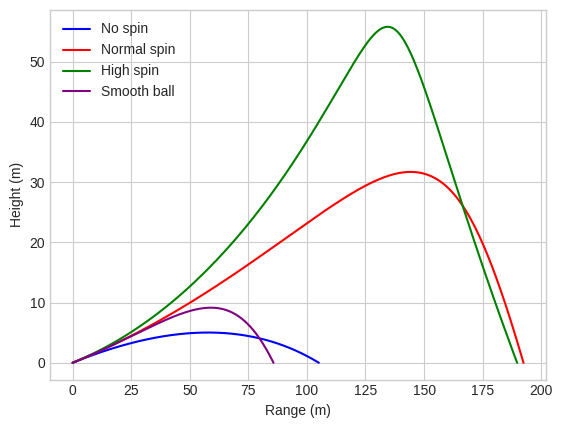

In [ ]:
#make your plotting code here
plt.figure()
plt.plot(r_a[:, 0],r_a[:, 1], label= 'No spin', color = 'blue')
plt.plot(r_b[:, 0],r_b[:, 1], label = 'Normal spin', color = 'red')
plt.plot(r_c[:, 0],r_c[:, 1], label = 'High spin', color = 'green')
plt.plot(r_d[:, 0],r_d[:, 1], label = 'Smooth ball', color = 'purple')
plt.legend()
plt.xlabel('Range (m)')
plt.ylabel('Height (m)')
plt.show()

## The Elfego Baca Golf Shoot!

In the Elfego Baca Golf Shoot, players tee off from **Socorro Peak ("M" Mountain)**, which is 2,219 meters (7,280 ft) high. The "green" is at the NMT golf course, 812 meters below the tee, at an altitude of 1,407 m (4,615 ft).

The horizontal distance to the NMT clubhouse is over 3,500 meters.

Find the **optimal launch angle** to get the maximum possible horizontal range from the first shot?  Can a "perfect shot" (no wind) theoretically reach the green?

To solve this, use **`scipy.optimize.minimize_scalar`**. This powerful tool will automatically find the angle that maximizes the range.

This requires a new setup:
1.  A new **derivatives function** that calculates air density based on the *absolute* altitude (relative altitude + 2,219 m).
2.  A new **event function** that stops the simulation when the ball's height is -812 m (the green's level relative to the tee).
3.  An *objective function** (`get_elfego_range`) that `scipy.optimize` can call to test different angles.

In [ ]:
# --- 1. Define new functions for the Elfego Baca Challenge ---

def derivatives_elfego(t_val, state, S_val, C_function):
    """
    Derivatives function for the Elfego challenge.
    Calculates air density based on ABSOLUTE altitude.
    """
    r_vec = state[0:2]# same as in your other function
    p_vec = state[2:4]# same as in your other function

    v_vec =p_vec/m#
    v_mag = np.linalg.norm(v_vec)#

    if v_mag == 0:
        v_hat = np.array([0.0, 0.0])
    else:
        v_hat = v_vec / v_mag

    # --- changes ---------
    # y_state[1] is the altitude *relative to the tee*.
    # We must add the tee's altitude (2219m) to get the
    # true absolute altitude for the air density calculation.
    y_absolute = r_vec[1] + 2219.0
    current_rho = get_air_density(y_absolute)#
    # -----------------------

    # Forces (all same as before, but using new current_rho)
    C = C_function(v_mag)
    F_drag = -C*current_rho*A*v_mag**2*v_hat#
    F_magnus = np.array([-S_val*p_vec[1], S_val*p_vec[0]])#
    F_net =  F_gravity+F_drag+F_magnus#

    # Return derivatives
    dr_dt = v_vec#
    dp_dt = F_net#
    return np.concatenate((dr_dt, dp_dt))

def event_hit_green(t, y_state, S_val, C_function):
    """
    Event function to stop when the ball drops 812m to the green's level.
    """
    # y_state[1] is relative altitude. Stop when it's -812.
    return y_state[1] + 812.0

event_hit_green.terminal = True # Stop the integration
event_hit_green.direction = -1  # Only trigger when going down

# --- 2. Define the "Objective Function" for the optimizer ---

def get_elfego_range(angle_deg):
    """
    Runs a single simulation for a given angle (in degrees)
    and returns the final horizontal range.
    """
    # Use standard "normal spin" for this shot
    S_val = S_omega_m_normal
    C_func = C_dimpled

    # 2a. Calculate new initial p and r
    rad = np.deg2rad(angle_deg)
    r_init = np.array([0.0, 0.0]) # Start at (0,0) relative to tee
    v_init = np.array([v0_mag*np.cos(rad), v0_mag*np.sin(rad)])
    p_init = m*v_init
    y_state_init = np.concatenate((r_init, p_init))

    # 2b. Run the simulation
    sol = solve_ivp(
        fun=derivatives_elfego,  # Use the new derivatives
        t_span=(0, 200),         # Allow up to 200s of flight time
        y0=y_state_init,
        method='RK45',
        args=(S_val, C_func),
        events=event_hit_green,  # Use the new event
        dense_output=True
    )

    # 2c. Get the final range
    max_range = sol.y[0, -1] # Final x-position

    # Add a print to see the optimizer working
    print(f"  Testing Angle: {angle_deg:.2f} deg -> Range: {max_range:.2f} m")

    # We return the NEGATIVE range because the function is a MINIMIZER
    return -max_range

# --- 3. Run the Optimizer! ---
print("Running Elfego Baca optimization...\n")

# We will search for the best angle between -20 (downward) and 45 (upward) degrees
# 'bounded' method is good for this.
opt_result = minimize_scalar(
    get_elfego_range,     # The function to minimize
    bounds=(-20, 45),     # Search between -20 and +45 degrees
    method='bounded'
)

print("\n...Optimization complete!")
print("\n--- Elfego Baca Challenge Results ---")
print(f"Optimal Launch Angle: {opt_result.x:.2f} degrees")
print(f"Maximum Horizontal Range: {-opt_result.fun:.2f} m")

if -opt_result.fun > 3500:
    print("\nResult: THEORETICALLY, YES! A perfect shot could reach the green.")
else:
    print("\nResult: Looks like it's just short. You'll need a second shot!")

Running Elfego Baca optimization...

  Testing Angle: 4.83 deg -> Range: 1015.57 m
  Testing Angle: 20.17 deg -> Range: 1000.81 m
  Testing Angle: -4.66 deg -> Range: 1015.25 m
  Testing Angle: 0.50 deg -> Range: 1016.38 m
  Testing Angle: 0.48 deg -> Range: 1016.38 m
  Testing Angle: 0.66 deg -> Range: 1016.38 m
  Testing Angle: 2.25 deg -> Range: 1016.26 m
  Testing Angle: 0.68 deg -> Range: 1016.38 m
  Testing Angle: 0.68 deg -> Range: 1016.38 m
  Testing Angle: 0.68 deg -> Range: 1016.38 m
  Testing Angle: 0.68 deg -> Range: 1016.38 m
  Testing Angle: 0.67 deg -> Range: 1016.38 m
  Testing Angle: 0.68 deg -> Range: 1016.38 m
  Testing Angle: 0.67 deg -> Range: 1016.38 m
  Testing Angle: 0.68 deg -> Range: 1016.38 m

...Optimization complete!

--- Elfego Baca Challenge Results ---
Optimal Launch Angle: 0.68 degrees
Maximum Horizontal Range: 1016.38 m

Result: Looks like it's just short. You'll need a second shot!
